In [4]:
#convert Json to CSV
import json 
import csv
import sys

def json_to_csv(json_file, csv_file):   
    with open(json_file) as f:
        data = json.load(f)
    csv_file = open(csv_file, 'w')
    csv_writer = csv.writer(csv_file)
    count = 0
    for i in data:
        if count == 0:
            header = i.keys()
            csv_writer.writerow(header)
            count += 1
        csv_writer.writerow(i.values())
    csv_file.close()

if __name__ == "__main__":  
    json_file = "hindi_songs_with_sentiment.json"
    csv_file = "hindi_songs_with_sentiment.csv"
    json_to_csv(json_file, csv_file)
    print("Conversion completed successfully")

Conversion completed successfully


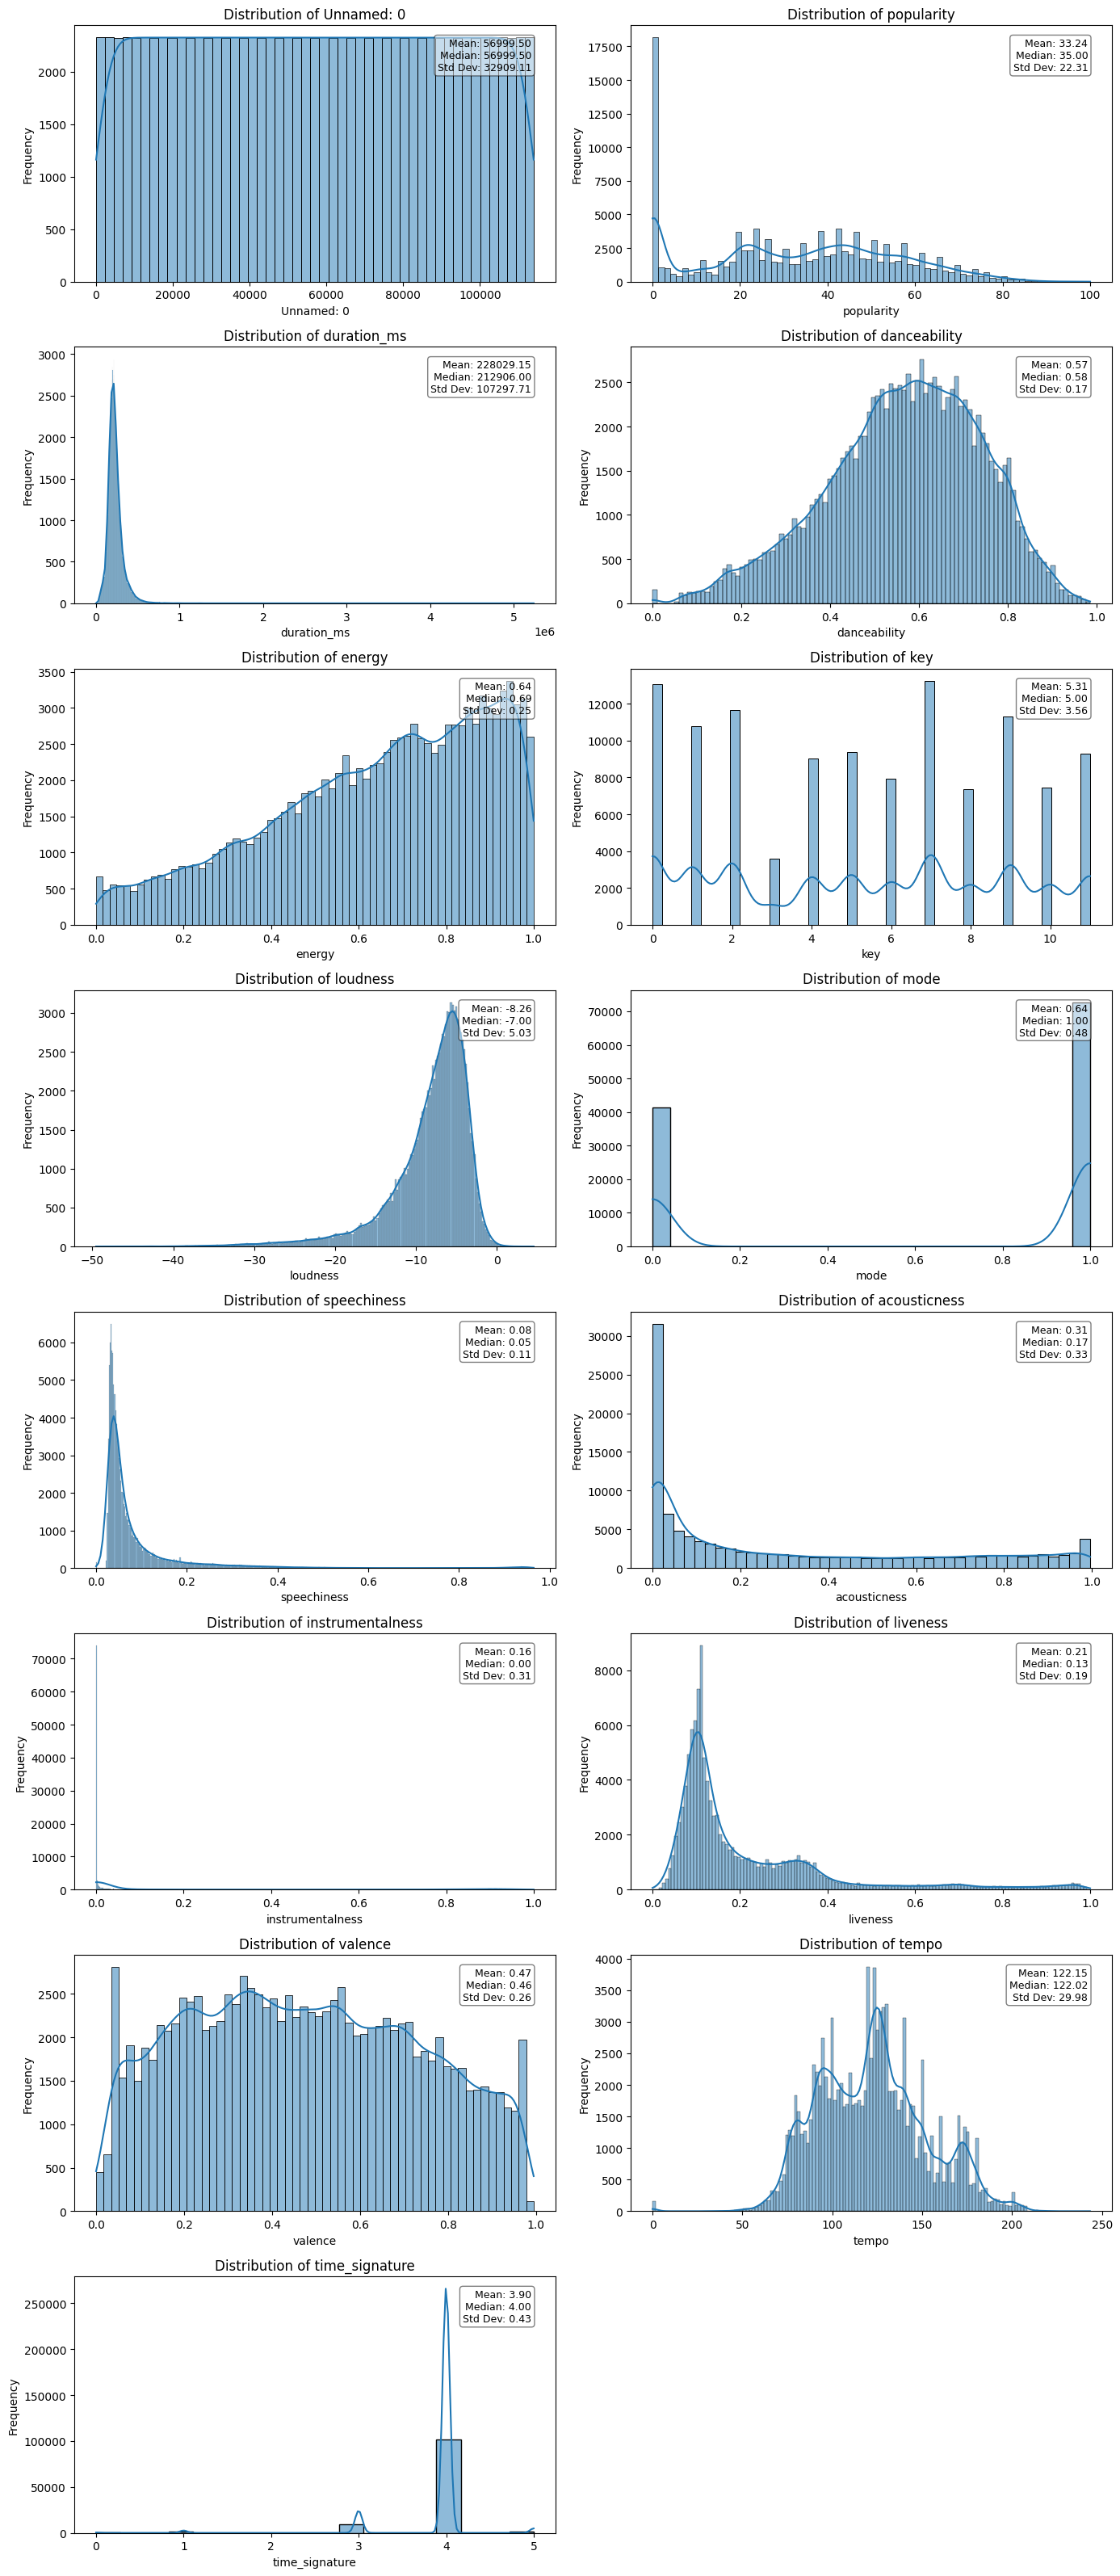

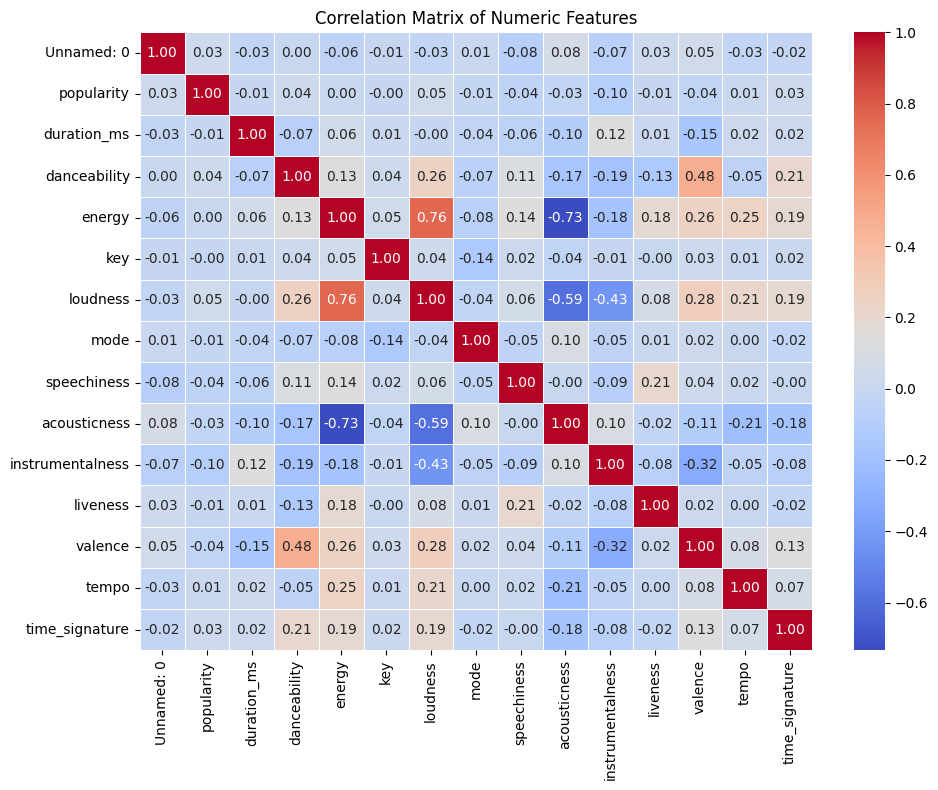

Basic statistics for numeric features:
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('../../spotify_features/dataset.csv')

# Identify numeric columns (excluding any ID columns)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# If there are any ID columns you want to exclude from plotting, remove them here
# For example: numeric_columns = [col for col in numeric_columns if 'id' not in col.lower()]

# Create a figure with subplots based on the number of numeric features
n_features = len(numeric_columns)
n_rows = (n_features + 1) // 2  # Ceiling division for number of rows
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Create histograms for each numeric feature
for i, column in enumerate(numeric_columns):
    if i < len(axes):
        # Create histogram
        sns.histplot(df[column].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {column}')
        axes[i].set_ylabel('Frequency')
        
        # Add descriptive statistics as text
        stats_text = f"Mean: {df[column].mean():.2f}\n"
        stats_text += f"Median: {df[column].median():.2f}\n"
        stats_text += f"Std Dev: {df[column].std():.2f}"
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                     fontsize=9, va='top', ha='right', 
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('hindi_songs_numeric_features_spotify.png', dpi=300)
plt.show()

# Additionally, create a correlation matrix for the numeric features
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('hindi_songs_correlation_matrix_spotify.png', dpi=300)
plt.show()

# Print basic statistics for numeric columns
print("Basic statistics for numeric features:")
print(df[numeric_columns].describe())